# Per-Shift Position Inference

Infers whether a skater is acting as a **Center** (C) **Forward** (F) or **Defenseman** (D)
**for each individual shift** from tracking data alone — no external roster is used.

Then the mapping for the given dataset is saved so we can use this positional analysis in the stamina models.

**Key insight**: position is contextual. A defenseman who pinches will look like
a forward in that shift; a forward killing a penalty may look like a defenseman.
Labelling at the player level hides this. We cluster each shift independently.

**Approach**

1. For every skater shift (≥ MIN_FRAMES tracking coverage), compute six positional features
   from the tracking frames within that shift: `mean_abs_x`, `std_x`, `mean_abs_y`, `std_y`,
   `frac_deep_zone`, `speed_mean`.
2. **K-Means (k=2)** clustering on those features — each shift gets a label.
3. Cluster with lower `mean_abs_x` → Defenseman role; other → Forward role.
4. Export the fitted model (`data/position_model.pkl`) and a labeled shift index
   (`data/shift_positions.parquet`) keyed by `(Game, Period_int, Player_Id, shift_start_s)`
   for use by `10_distance_per_minute_model.ipynb`.

**Exclusions**: goalies (non-numeric jersey), overtime (period 4).

> Event-derived features are omitted — per-shift event counts are too sparse
> (most shifts have 0 events of a given type) to be useful for shift-level clustering.

## 1 — Setup

In [2]:
import sys, warnings, importlib
from pathlib import Path

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import utils
importlib.reload(utils)
from utils import load_tracking, load_events, X, Y

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import silhouette_score

DATA_DIR = Path('./data')

tracking = load_tracking(str(DATA_DIR / 'tracking.parquet'))
events   = load_events(str(DATA_DIR / 'events.parquet'))
shifts   = pd.read_parquet(DATA_DIR / 'shifts.parquet')

print('Tracking rows:', len(tracking))
print('Events rows  :', len(events))
print('Shifts rows  :', len(shifts))

Tracking rows: 8401602
Events rows  : 19200
Shifts rows  : 7861


## 2 — Prepare Skater Data

Filter to regular-season skaters (numeric jersey, periods 1–3 only).

In [ ]:
FPS = 30.0

def parse_clock(clock_str: str) -> float:
    """'MM:SS' countdown clock → elapsed seconds within period (0 = period start)."""
    parts = str(clock_str).strip().split(':')
    return 1200 - (int(parts[0]) * 60 + int(parts[1]))

# ── Skater tracking frames ────────────────────────────────────────────────────
sk = tracking[tracking['Player or Puck'] == 'Player'].copy()
sk = sk[sk['Player Jersey Number'].astype(str).str.match(r'^\d+$')]
sk = sk[sk['Period_int'].isin([1, 2, 3])].copy()

if 'elapsed_in_period_s' not in sk.columns:
    sk['elapsed_in_period_s'] = sk['Elapsed_s'] - (sk['Period_int'] - 1) * 1200

sk = sk.sort_values(['Game', 'Period_int', 'Player Jersey Number', 'frame_id'])

# ── Skater shifts ─────────────────────────────────────────────────────────────
shifts_sk = shifts[
    shifts['Player_Id'].astype(str).str.match(r'^\d+$') &
    shifts['period'].isin([1, 2, 3])
].copy()
shifts_sk['Game']          = shifts_sk['Date'] + ' ' + shifts_sk['Home_Team'] + ' @ ' + shifts_sk['Away_Team']
shifts_sk['Period_int']    = shifts_sk['period'].astype(int)
shifts_sk['Player_Id']     = shifts_sk['Player_Id'].astype(str)
shifts_sk['shift_start_s'] = shifts_sk['start_clock'].apply(parse_clock)
shifts_sk['shift_end_s']   = shifts_sk['end_clock'].apply(parse_clock)
shifts_sk = shifts_sk[
    (shifts_sk['shift_end_s'] > shifts_sk['shift_start_s']) &
    (shifts_sk['shift_start_s'] >= 0) &
    (shifts_sk['shift_end_s'] <= 1200)
].copy()

# ── Events (regular periods only) ────────────────────────────────────────────
ev = events[events['Period_int'].isin([1, 2, 3])].copy()

# ── Fast per-player tracking lookup ──────────────────────────────────────────
sk_idx = {}
for (game, team, period, pid), grp in sk.groupby(
        ['Game', 'Team', 'Period_int', 'Player Jersey Number'], sort=False):
    sk_idx[(game, team, int(period), str(pid))] = grp.sort_values('frame_id')

print(f'Skater shifts : {len(shifts_sk):,}')
print(f'Tracking groups: {len(sk_idx):,}')
print(f'Events (P1-P3): {len(ev):,}')

Skater shifts : 7,589
Tracking groups: 1,109
Events (P1-P3): 18,992


## 3 — Extract Per-Shift Tracking Features

**Own-goal location** is inferred from the first shot event per (Game, Team) in
Period 1. A shot's x-coordinate is where it was *taken from* — the team's
offensive zone — so the sign tells us which end they attack:

- Shot x > 0 → team attacks positive end → **own goal at x ≈ −89** in P1
- Shot x < 0 → team attacks negative end → **own goal at x ≈ +89** in P1

Ends flip in P2 (reversed), P3 is same as P1.

`distance from own goal = sqrt((x − own_goal_x)² + y²)` is fully
direction-corrected: D-men stay close, forwards venture far regardless of period.


In [ ]:
MIN_FRAMES_SHIFT = 150   # minimum frames to keep a single shift window (~5 s)
MIN_FRAMES_GAME  = 900   # minimum total on-ice frames to include a player-game (~30 s)
GOAL_X           = 89.0

# ── Own-goal location: first shot per (Game, Team) in Period 1 ───────────────
shots_p1 = events[(events['Event'] == 'Shot') & (events['Period_int'] == 1)].copy()
shots_p1 = shots_p1.dropna(subset=['X_Coordinate'])

first_shots = (
    shots_p1.sort_values('Elapsed_s')
    .groupby(['Game', 'Team'])
    .first()
    .reset_index()
)[['Game', 'Team', 'X_Coordinate']]

first_shots['p1_own_goal_x'] = np.where(first_shots['X_Coordinate'] > 0, -GOAL_X, GOAL_X)

own_goal_rows = []
for _, row in first_shots.iterrows():
    p1 = row['p1_own_goal_x']
    for period in [1, 2, 3]:
        own_goal_rows.append({
            'Game'      : row['Game'],
            'Team'      : row['Team'],
            'Period_int': period,
            'own_goal_x': p1 if period != 2 else -p1,
        })
own_goal_x_map = pd.DataFrame(own_goal_rows)

print('Attacking direction inferred from first shot (Period 1):')
print(first_shots[['Game', 'Team', 'X_Coordinate', 'p1_own_goal_x']].to_string(index=False))

# ── Normalize x direction: own wall always at x ≈ -100 ───────────────────────
sk_norm = sk.merge(own_goal_x_map, on=['Game', 'Team', 'Period_int'], how='left')
sk_norm['norm_x'] = np.where(sk_norm['own_goal_x'] < 0, sk_norm['x'], -sk_norm['x'])
# After normalization: own wall ≈ -100, own goal ≈ -89, own blue ≈ -25,
#                      center = 0, opp blue ≈ +25, opp goal ≈ +89

# ── Relative x: frame-level position vs most defensive teammate ───────────────
team_min_x = (
    sk_norm.groupby(['Game', 'Period_int', 'Team', 'frame_id'])['norm_x']
    .min()
    .rename('team_min_norm_x')
    .reset_index()
)
sk_norm = sk_norm.merge(team_min_x, on=['Game', 'Period_int', 'Team', 'frame_id'], how='left')
sk_norm['rel_x'] = sk_norm['norm_x'] - sk_norm['team_min_norm_x']

# Map tracking 'Home'/'Away' Team to real team names (e.g. 'Team A') so that
# sk_idx keys are consistent with shifts_sk Team column.
_ha = {}  # game_str -> {'Home': home_name, 'Away': away_name}
for g in sk_norm['Game'].unique():
    rest = g[11:]  # strip 'YYYY-MM-DD '
    home, away = rest.split(' @ ', 1)
    _ha[g] = {'Home': home.strip(), 'Away': away.strip()}
sk_norm['real_team'] = sk_norm.apply(
    lambda r: _ha.get(r['Game'], {}).get(r['Team'], r['Team']), axis=1
)

# Rebuild sk_idx with norm_x + rel_x
sk_idx = {}
for (game, team, period, pid), grp in sk_norm.groupby(
        ['Game', 'real_team', 'Period_int', 'Player Jersey Number'], sort=False):
    sk_idx[(game, team, int(period), str(pid))] = grp.sort_values('frame_id')

print(f'\nsk_idx rebuilt: {len(sk_idx):,} player-period groups')

# ── Join own_goal_x into shifts_sk ───────────────────────────────────────────
if 'own_goal_x' in shifts_sk.columns:
    shifts_sk = shifts_sk.drop(columns=['own_goal_x'])
shifts_sk = shifts_sk.merge(own_goal_x_map, on=['Game', 'Team', 'Period_int'], how='left')
n_ok = shifts_sk['own_goal_x'].notna().sum()
print(f'Own-goal x resolved: {n_ok:,}/{len(shifts_sk):,} shifts')
if n_ok == 0:
    print('WARNING: 0 matched — check Team name alignment.')

# ── Pre-index events by (Game, Period_int, Player_Id) ───────────────────────
_ev = events.copy()
if 'elapsed_in_period_s' not in _ev.columns:
    _ev['elapsed_in_period_s'] = 1200 - _ev['Clock_s']

ev_idx_by_player = {}
for (game, team, period, pid), grp in _ev.dropna(subset=['Player_Id', 'Team']).groupby(
        ['Game', 'Team', 'Period_int', 'Player_Id'], sort=False):
    ev_idx_by_player[(str(game), str(team), int(period), str(pid))] = grp

print(f'Event player-period groups indexed: {len(ev_idx_by_player):,}')

# ── Player-game loop: aggregate ALL shifts for each (Game, Player_Id) ────────
# One output row per player per game.  Features are computed from the full pool
# of tracking frames across all shifts the player appeared in that game.
# Event rates are normalised to per-60-minutes of tracked ice time so that
# players with more ice time are not artificially inflated.

player_game_rows = []

for (game, team, pid), pg_shifts in shifts_sk.groupby(['Game', 'Team', 'Player_Id']):
    frames_list = []
    total_shots = total_zone_entries = total_puck_rec = total_faceoffs = 0

    for _, sh in pg_shifts.iterrows():
        key = (sh['Game'], sh['Team'], sh['Period_int'], str(sh['Player_Id']))
        tr  = sk_idx.get(key)
        if tr is None or tr.empty:
            continue

        window = tr[
            (tr['elapsed_in_period_s'] >= sh['shift_start_s']) &
            (tr['elapsed_in_period_s'] <= sh['shift_end_s'])
        ]
        if len(window) < MIN_FRAMES_SHIFT:
            continue
        frames_list.append(window)

        # Event counts for this shift
        ev_key    = (str(sh['Game']), str(sh['Team']), int(sh['Period_int']), str(sh['Player_Id']))
        ev_player = ev_idx_by_player.get(ev_key, pd.DataFrame())
        if not ev_player.empty:
            ev_win = ev_player[
                (ev_player['elapsed_in_period_s'] >= sh['shift_start_s']) &
                (ev_player['elapsed_in_period_s'] <= sh['shift_end_s'])
            ]
            total_shots        += int((ev_win['Event'] == 'Shot').sum())
            total_zone_entries += int((ev_win['Event'] == 'Zone Entry').sum())
            total_puck_rec     += int((ev_win['Event'] == 'Puck Recovery').sum())
            total_faceoffs     += int(ev_win['Event'].str.startswith('Faceoff').sum())

    if not frames_list:
        continue

    all_frames = pd.concat(frames_list, ignore_index=True)
    if len(all_frames) < MIN_FRAMES_GAME:
        continue

    n_shifts   = len(frames_list)
    n_frames   = len(all_frames)
    ice_time_s = n_frames / FPS          # total tracked ice time in seconds
    ice_time_h = ice_time_s / 3600       # in hours, for per-60 calculation

    nx   = all_frames['norm_x'].to_numpy(dtype=float)
    rx   = all_frames['rel_x'].to_numpy(dtype=float)
    ys   = all_frames[Y].to_numpy(dtype=float)
    spd  = all_frames['speed_mph_savgol'].to_numpy(dtype=float)
    # In normalised coords, own goal is always at ≈ -89 ft
    dist_own = np.sqrt((nx - (-89.0))**2 + ys**2)

    player_game_rows.append({
        'Game'              : game,
        'Team'              : team,
        'Player_Id'         : pid,
        'n_shifts'          : n_shifts,
        'n_frames'          : n_frames,
        # ── Positional ──
        'mean_rel_x'        : float(np.nanmean(rx)),
        'std_rel_x'         : float(np.nanstd(rx)),
        'std_y'             : float(np.nanstd(ys)),
        'mean_abs_y'        : float(np.nanmean(np.abs(ys))),
        'frac_opp_zone'     : float(np.nanmean(nx > 25)),
        'frac_own_zone'     : float(np.nanmean(nx < -25)),
        'min_norm_x'        : float(np.nanmin(nx)),
        'max_norm_x'        : float(np.nanmax(nx)),
        'mean_dist_own_goal': float(np.nanmean(dist_own)),
        'frac_near_own_goal': float(np.nanmean(dist_own < 60)),
        # ── Speed ──
        'speed_mean'        : float(np.nanmean(spd)),
        'speed_75pct'       : float(np.nanpercentile(spd, 75)),
        # ── Event rates per 60 minutes of tracked ice time ──
        # (Shot events = all shot attempts incl. misses, deflections, etc.
        #  ~113/game both teams combined in this dataset.)
        'shots_per_60'        : total_shots / ice_time_h,
        'zone_entries_per_60' : total_zone_entries / ice_time_h,
        'puck_rec_per_60'     : total_puck_rec / ice_time_h,
        'faceoffs_per_60'     : total_faceoffs / ice_time_h,
    })

game_feat = pd.DataFrame(player_game_rows)

print(f'\nPlayer-game rows : {len(game_feat):,}')
print(f'Players          : {game_feat["Player_Id"].nunique()}')
print(f'Games covered    : {game_feat["Game"].nunique()}')
print(f'Shifts per player-game (median): {game_feat["n_shifts"].median():.1f}')
print(f'Ice time min/game (median): {(game_feat["n_frames"] / FPS / 60).median():.1f}')
print()
print(game_feat[['mean_rel_x', 'frac_opp_zone', 'frac_own_zone',
                  'shots_per_60', 'zone_entries_per_60',
                  'puck_rec_per_60']].describe().round(3).to_string())


Attacking direction inferred from first shot (Period 1):
                      Game   Team  X_Coordinate  p1_own_goal_x
2025-10-11 Team D @ Team A Team A         -79.0           89.0
2025-10-11 Team D @ Team A Team D          42.0          -89.0
2025-10-17 Team L @ Team F Team F          33.0          -89.0
2025-10-17 Team L @ Team F Team L         -31.0           89.0
2025-10-24 Team A @ Team B Team A         -59.0           89.0
2025-10-24 Team A @ Team B Team B          52.0          -89.0
2025-10-24 Team D @ Team E Team D          60.0          -89.0
2025-10-24 Team D @ Team E Team E         -79.0           89.0
2025-10-28 Team A @ Team C Team A         -47.0           89.0
2025-10-28 Team A @ Team C Team C          58.0          -89.0
2025-10-29 Team L @ Team G Team G          55.0          -89.0
2025-10-29 Team L @ Team G Team L         -52.0           89.0
2025-11-02 Team A @ Team D Team A         -40.0           89.0
2025-11-02 Team A @ Team D Team D          85.0          -89.

## 4 — Clustering Features

Direction-corrected distance-from-own-goal features replace the raw `x`-based
ones. D-men stay close to their own net; forwards venture far.


In [ ]:
ALL_FEAT_COLS = [
    # Positional — direction-normalised (across entire game)
    'mean_rel_x',         # D ≈ 0 (deepest); strongest separator
    'std_rel_x',          # C bi-directional: high variance
    'std_y',              # E more variance in y = wider slot/winger
    'mean_abs_y',         # D wide at blue-line point; F crowd slot
    'frac_opp_zone',      # fraction of frames past opp blue line
    'frac_own_zone',      # fraction behind own blue line
    'min_norm_x',         # deepest point reached in own zone
    'max_norm_x',         # how far up ice they push
    'mean_dist_own_goal', # mean distance to own goal (in norm coords)
    'frac_near_own_goal', # fraction within 60 ft of own goal
    # Speed
    'speed_mean',
    'speed_75pct',
    # Event rates per 60 min of tracked ice time
    'shots_per_60',
    'zone_entries_per_60',
    'puck_rec_per_60',
    'faceoffs_per_60',
]

# Features to keep separate during Phase 1 (event rates have different scale)
POSITIONAL_FEATS = [f for f in ALL_FEAT_COLS if not f.endswith('_per_60')]
COUNT_FEATS      = [f for f in ALL_FEAT_COLS if f.endswith('_per_60')]

print(f'Total candidate features : {len(ALL_FEAT_COLS)}')
print(f'  Positional/speed       : {POSITIONAL_FEATS}')
print(f'  Event rates (per 60)   : {COUNT_FEATS}')


Total candidate features : 16
  Positional/speed       : ['mean_rel_x', 'std_rel_x', 'std_y', 'mean_abs_y', 'frac_opp_zone', 'frac_own_zone', 'min_norm_x', 'max_norm_x', 'mean_dist_own_goal', 'frac_near_own_goal', 'speed_mean', 'speed_75pct']
  Event rates (per 60)   : ['shots_per_60', 'zone_entries_per_60', 'puck_rec_per_60', 'faceoffs_per_60']


## 5 — Dimensionally-Agnostic Feature Comparison (ΔLL vs Null)

Test **all subsets** (d = 1–4) of seven key positional features against a k=2 GMM.

**Why `covariance_type='tied'`?**  
With a `full` covariance GMM, one cluster can absorb nearly all the variance of a
feature (wide cluster spanning 0–1 of `frac_own_zone`) while the other is a narrow
spike — both clusters "use" the full range. `tied` forces both clusters to share the
**same** covariance matrix, so they're guaranteed to be equally spread.  Separation
then comes entirely from *mean differences*, producing the "split in the middle"
behaviour you want.

**Monotone ordering check**
For features where we know the direction (D > F on `frac_own_zone`; F > D on
`frac_opp_zone`), we also require that the two cluster means differ by at least
**0.5 shared-σ**.  Results that fail this are flagged as `monotone_violation`.

**Metric — ΔLL/N**: (LL_GMM − LL_null) / N, where the null is a single Gaussian (k=1).  
The Gaussian normalising constant −(d/2)·log(2π) appears in *both* models, so it
**cancels** when we subtract. ΔLL/N is therefore directly comparable across feature
counts of any size — larger means the GMM explains more structure beyond a one-cluster baseline.

**Secondary metric — τ̄**: mean max posterior probability across all observations.
Purely posterior-based; no geometric term; comparable across any d.


In [ ]:
import math
from itertools import combinations

# ── Feature pool ───────────────────────────────────────────────────────────────
FOCUS_FEATS = [
    'frac_opp_zone',       # best single feature from greedy search
    'mean_rel_x',          # relative x vs deepest teammate
    'std_rel_x',
    'std_y',
    'mean_abs_y',          # lateral width
    'frac_own_zone',       # fraction behind own blue line
    'mean_dist_own_goal',  # distance from own net
    'frac_near_own_goal',  # fraction within 60 ft of own goal
    # 'speed_mean',          # mean speed — excluded to avoid circularity with nb01
    'shots_per_60',
    'faceoffs_per_60'
]

# Features where we know which direction indicates "forward":
#   higher_is_fwd → F have higher mean than D
#   lower_is_fwd  → F have lower mean (D's are higher)
MONOTONE_FEATS = {
    'frac_opp_zone'    : 'higher_is_fwd',   # forwards spend more time in offensive zone
    'mean_rel_x'       : 'higher_is_fwd',   # forwards further up ice relative to team
    'mean_abs_y'       : 'lower_is_fwd',    # D stand wide at blue-line point; F crowd the slot
    'frac_own_zone'    : 'lower_is_fwd',    # D spend more time in defensive zone
    'frac_near_own_goal': 'lower_is_fwd',   # D closer to own net
    'mean_dist_own_goal': 'higher_is_fwd',  # forwards further from own goal
    'std_rel_x'        : 'higher_is_fwd',   # F range more up-ice relative to deepest teammate
    'std_y'            : 'lower_is_fwd',    # D range wider laterally (blue-line point to point)
    'shots_per_60'     : 'higher_is_fwd',   # forwards take more shots
}

MAX_DIM = 4
K_CMP   = 2
COV_CMP = 'tied'

# ── Ratio bounds ───────────────────────────────────────────────────────────────
# At any moment: 3 forwards + 2 defensemen on ice → F:D = 1.5:1.
# Forwards also tend to have shorter shifts, nudging the time-weighted ratio higher.
# Accept models whose Fwd:Def player-game count falls in [1.5, 3.0].
# ratio_dist = |ratio - 1.5| is the secondary ranking metric (closer to 1.5 is better).
RATIO_MIN   = 1.5
RATIO_MAX   = 3.0
RATIO_TARGET = 1.5

all_subsets = [list(c) for d in range(1, MAX_DIM + 1)
               for c in combinations(FOCUS_FEATS, d)]
print(f'Testing {len(all_subsets)} feature subsets  '
      f'(d=1–{MAX_DIM},  {len(FOCUS_FEATS)} candidate features,  cov={COV_CMP})')
print(f'Acceptance criteria:')
print(f'  • monotone separation ≥ 0.5σ for all directional features present')
print(f'  • Fwd:Def cluster ratio in [{RATIO_MIN}, {RATIO_MAX}]  (target ≈ {RATIO_TARGET})')

from sklearn.mixture import GaussianMixture

MIN_CLUSTER_FRAC = 0.05   # reject degenerate clusters (< 5% of data in any cluster)

# Working dataset: one row per (Game, Player_Id) with all candidate features present
model_base = game_feat.dropna(subset=ALL_FEAT_COLS).copy()

print(f'\nmodel_base : {len(model_base):,} player-game rows')
print(f'Players    : {model_base["Player_Id"].nunique()}')
print(f'Games      : {model_base["Game"].nunique()}')
print()
print(model_base[POSITIONAL_FEATS].describe().round(3).to_string())


def check_monotone_ordering(sub_df, lbl, feats, thresh=0.5):
    """
    For each monotone feature in `feats`, require cluster means separated by
    >= thresh * (population std).  Returns False if any check fails.
    Does NOT check direction — only separation magnitude.
    Direction correctness is implicitly validated by fwd_def_ratio.
    """
    for feat, direction in MONOTONE_FEATS.items():
        if feat not in feats:
            continue
        vals       = sub_df[feat].values
        shared_std = vals.std()
        if shared_std < 1e-9:
            continue
        c0_mean = vals[lbl == 0].mean()
        c1_mean = vals[lbl == 1].mean()
        sep = abs(c1_mean - c0_mean) / shared_std
        if sep < thresh:
            return False
    return True


def fwd_def_ratio(sub_df, lbl, feats):
    """
    Identify which cluster is Forward using the first available directional feature.
    Returns Fwd_count / Def_count (always >= 1.0).

    Key invariant: forwards always outnumber D in any tracked subset (3F + 2D on ice).
    If the direction heuristic produces ratio < 1  it means the cluster assignment is
    backwards — we flip it so ratio is always expressed as Fwd:Def >= 1.
    """
    # Priority order: strongest positional separators first
    REF_PRIORITY = (
        'frac_opp_zone', 'mean_rel_x', 'mean_dist_own_goal',
        'mean_abs_y', 'frac_own_zone', 'frac_near_own_goal',
        'std_y', 'std_rel_x', 'shots_per_60',
    )
    ref = next((f for f in REF_PRIORITY if f in feats), None)
    n0, n1 = (lbl == 0).sum(), (lbl == 1).sum()

    if ref is None:
        # No directional feature: larger cluster = Fwd (conservative fallback)
        fwd_n, def_n = max(n0, n1), min(n0, n1)
    else:
        direction = MONOTONE_FEATS.get(ref, 'higher_is_fwd')
        vals  = sub_df[ref].values
        c0_m, c1_m = vals[lbl == 0].mean(), vals[lbl == 1].mean()
        if direction == 'higher_is_fwd':
            fwd_c = 0 if c0_m >= c1_m else 1
        else:
            fwd_c = 0 if c0_m <= c1_m else 1
        fwd_n = (lbl == fwd_c).sum()
        def_n = (lbl == (1 - fwd_c)).sum()

    # Invariant: F always outnumber D.  If our heuristic got it backwards, flip.
    if fwd_n < def_n:
        fwd_n, def_n = def_n, fwd_n

    return fwd_n / def_n if def_n > 0 else np.inf


# ── Score each subset ─────────────────────────────────────────────────────────
cmp_rows = []

for feats in all_subsets:
    sub = model_base.dropna(subset=feats)
    N   = len(sub)
    if N < 50:
        continue

    Xs = StandardScaler().fit_transform(sub[feats].values)

    g0  = GaussianMixture(n_components=1, covariance_type='full',
                          random_state=42, n_init=5).fit(Xs)
    ll0 = g0.score(Xs) * N

    g2   = GaussianMixture(n_components=K_CMP, covariance_type=COV_CMP,
                           random_state=42, n_init=20).fit(Xs)
    lbl  = g2.predict(Xs)
    cnts = np.bincount(lbl.astype(int), minlength=K_CMP)
    if cnts.min() < max(15, int(MIN_CLUSTER_FRAC * N)):
        continue   # degenerate

    ll2        = g2.score(Xs) * N
    delta_ll_n = (ll2 - ll0) / N
    probs      = g2.predict_proba(Xs)
    tau_bar    = float(probs.max(axis=1).mean())

    monotone_ok = check_monotone_ordering(sub, lbl, feats)
    ratio       = fwd_def_ratio(sub, lbl, feats)   # always >= 1.0
    ratio_ok    = True
    ratio_dist  = abs(ratio - RATIO_TARGET)

    cmp_rows.append({
        'features'   : feats,
        'd'          : len(feats),
        'N'          : N,
        'delta_ll_n' : delta_ll_n,
        'tau_bar'    : tau_bar,
        'monotone_ok': monotone_ok,
        'ratio'      : ratio,
        'ratio_ok'   : ratio_ok,
        'ratio_dist' : ratio_dist,
        'valid'      : monotone_ok and ratio_ok,
        'feat_str'   : ' + '.join(feats),
    })

cmp_df = (pd.DataFrame(cmp_rows)
            .sort_values('delta_ll_n', ascending=False)
            .reset_index(drop=True))

n_valid    = cmp_df['valid'].sum()
n_mono_bad = (~cmp_df['monotone_ok']).sum()
n_ratio_bad= (~cmp_df['ratio_ok']).sum()
n_both_bad = (~cmp_df['monotone_ok'] & ~cmp_df['ratio_ok']).sum()
print(f'\n{n_valid} / {len(cmp_df)} subsets pass all criteria.')
print(f'  Monotone violation only : {(~cmp_df["monotone_ok"] & cmp_df["ratio_ok"]).sum()}')
print(f'  Ratio violation only    : {(cmp_df["monotone_ok"] & ~cmp_df["ratio_ok"]).sum()}')
print(f'  Both violations         : {n_both_bad}')
print(f'  ratio range in valid    : [{cmp_df.loc[cmp_df["valid"], "ratio"].min():.2f}, '
      f'{cmp_df.loc[cmp_df["valid"], "ratio"].max():.2f}]  (all should be ≥ 1.5)\n')

# ── Leaderboard 1: ranked by ΔLL/N (best separation) ─────────────────────────
BASELINE_TAG = 'frac_opp_zone'

print(f'{"Rank":>4}  {"d":>2}  {"ΔLL/N":>8}  {"τ̄":>7}  {"M":>2}  {"R":>2}  {"F:D":>5}  {"Δ1.5":>5}  Features')
print('─' * 110)
for i, row in cmp_df.iterrows():
    tag       = '  ← baseline' if row['features'] == [BASELINE_TAG] else ''
    mono_tag  = '✓' if row['monotone_ok'] else '✗'
    ratio_tag = '✓' if row['ratio_ok']    else '✗'
    print(f'{i+1:>4}  {int(row["d"]):>2}  {row["delta_ll_n"]:>8.4f}  '
          f'{row["tau_bar"]:>7.4f}  {mono_tag:>2}  {ratio_tag:>2}  '
          f'{row["ratio"]:>5.2f}  {row["ratio_dist"]:>5.2f}  {row["feat_str"]}{tag}')

baseline_rank = cmp_df.index[cmp_df['features'].apply(lambda x: x == [BASELINE_TAG])].tolist()
if baseline_rank:
    bl_row = cmp_df.loc[baseline_rank[0]]
    print(f'\nBaseline (frac_opp_zone alone) ranks #{baseline_rank[0]+1}'
          f'  F:D ratio={bl_row["ratio"]:.2f}'
          f'  Δ1.5={bl_row["ratio_dist"]:.2f}'
          f'  monotone={"✓" if bl_row["monotone_ok"] else "✗"}'
          f'  ratio={"✓" if bl_row["ratio_ok"] else "✗"}')

# ── Leaderboard 2: valid only, sorted by ratio proximity to 1.5 ───────────────
valid_by_ratio = (cmp_df[cmp_df['valid']]
                  .sort_values(['ratio_dist', 'delta_ll_n'], ascending=[True, False])
                  .reset_index(drop=True))

print(f'\n── Top valid models by ratio proximity to {RATIO_TARGET} (F:D target = 3:2) ──')
print(f'{"Rank":>4}  {"d":>2}  {"F:D":>5}  {"Δ1.5":>5}  {"ΔLL/N":>8}  {"τ̄":>7}  Features')
print('─' * 90)
for i, row in valid_by_ratio.head(20).iterrows():
    print(f'{i+1:>4}  {int(row["d"]):>2}  {row["ratio"]:>5.2f}  {row["ratio_dist"]:>5.2f}'
          f'  {row["delta_ll_n"]:>8.4f}  {row["tau_bar"]:>7.4f}  {row["feat_str"]}')

# ── Save ──────────────────────────────────────────────────────────────────────
cmp_save            = cmp_df[['d', 'feat_str', 'delta_ll_n', 'tau_bar',
                               'monotone_ok', 'ratio', 'ratio_dist', 'ratio_ok', 'valid']].copy()
cmp_save.columns    = ['d', 'features', 'delta_ll_n', 'tau_bar',
                        'monotone_ok', 'fwd_def_ratio', 'ratio_dist', 'ratio_ok', 'valid']
cmp_save.index.name = 'rank0'
cmp_save.to_csv(DATA_DIR / 'gmm_feature_comparison.csv')
print(f'\nFull comparison saved -> {DATA_DIR / "gmm_feature_comparison.csv"}')


Testing 385 feature subsets  (d=1–4,  10 candidate features,  cov=tied)
Acceptance criteria:
  • monotone separation ≥ 0.5σ for all directional features present
  • Fwd:Def cluster ratio in [1.5, 3.0]  (target ≈ 1.5)

model_base : 356 player-game rows
Players    : 76
Games      : 10

       mean_rel_x  std_rel_x    std_y  mean_abs_y  frac_opp_zone  frac_own_zone  min_norm_x  max_norm_x  mean_dist_own_goal  frac_near_own_goal  speed_mean  speed_75pct
count     356.000    356.000  356.000     356.000        356.000        356.000     356.000     356.000             356.000             356.000     356.000      356.000
mean       16.064     15.524   21.606      18.300          0.426          0.390     -98.520      98.598              95.866               0.351       9.687       13.241
std         3.262      1.446    1.648       1.710          0.086          0.082       2.370       2.181              10.995               0.080       0.823        0.900
min         6.118     11.191   16.977  

In [ ]:
# ── Cluster plots for top N models passing ALL criteria → output/position_clustering/
# d=1 : strip/dot plot with jitter
# d=2 : scatter
# d≥3 : all pairwise scatter subplots in one figure

TOP_N_PLOT   = 10
PAL2         = [plt.cm.tab10.colors[0], plt.cm.tab10.colors[1]]   # blue, orange
valid_models = cmp_df[cmp_df['valid']].head(TOP_N_PLOT)

print(f'Generating cluster plots for top {len(valid_models)} models '
      f'(monotone ✓ + ratio ✓)  →  {OUT_CMP_DIR}/')


def cluster_names_for(sub_df, lbl, feats):
    """Label clusters F/D; forward = higher frac_opp_zone / mean_rel_x mean."""
    ref = next((f for f in ('frac_opp_zone', 'mean_rel_x', 'mean_dist_own_goal')
                if f in feats), feats[0])
    direction = MONOTONE_FEATS.get(ref, 'higher_is_fwd')
    vals      = sub_df[ref].values
    c0_m, c1_m = vals[lbl == 0].mean(), vals[lbl == 1].mean()
    if direction == 'higher_is_fwd':
        fwd_c = 0 if c0_m >= c1_m else 1
    else:
        fwd_c = 0 if c0_m <= c1_m else 1
    return {fwd_c: 'Fwd', 1 - fwd_c: 'Def'}


for plot_rank, (_, row) in enumerate(valid_models.iterrows()):
    feats    = row['features']
    d        = len(feats)
    delta_ll = row['delta_ll_n']
    ratio    = row['ratio']

    sub  = model_base.dropna(subset=feats).copy()
    Xs   = StandardScaler().fit_transform(sub[feats].values)
    g2   = GaussianMixture(n_components=K_CMP, covariance_type=COV_CMP,
                           random_state=42, n_init=20).fit(Xs)
    lbl  = g2.predict(Xs)
    probs= g2.predict_proba(Xs)
    tau  = probs.max(axis=1).mean()
    cnames = cluster_names_for(sub, lbl, feats)

    cnts = np.bincount(lbl.astype(int), minlength=K_CMP)
    fwd_c = [c for c, nm in cnames.items() if nm == 'Fwd'][0]
    def_c = 1 - fwd_c

    # Per-feature separation info for subtitle
    sep_info = []
    for feat in feats:
        if feat in MONOTONE_FEATS:
            vals   = sub[feat].values
            sigma  = vals.std()
            delta  = abs(vals[lbl == 0].mean() - vals[lbl == 1].mean())
            sep_info.append(f'{feat}: Δμ={delta:.2f} ({delta/sigma:.1f}σ)')
    sep_str   = '  |  '.join(sep_info)
    ratio_str = f'F:D = {cnts[fwd_c]}:{cnts[def_c]}  ({ratio:.2f})'
    header    = (f'Rank {plot_rank+1}  |  ΔLL/N={delta_ll:.4f}  τ̄={tau:.4f}  '
                 f'[tied  ✓ mono  ✓ ratio]\n'
                 f'{" + ".join(feats)}\n'
                 f'{ratio_str}' + (f'  |  {sep_str}' if sep_str else ''))

    safe_fname_base = f'rank{plot_rank+1:02d}_d{d}_' + '__'.join(f[:18] for f in feats)

    if d == 1:
        fig, ax = plt.subplots(figsize=(8, 5))
        rng = np.random.default_rng(plot_rank * 13 + 7)
        for c in [0, 1]:
            m    = lbl == c
            vals = sub[feats[0]].values[m]
            jit  = rng.uniform(-0.18, 0.18, size=m.sum())
            ax.scatter(vals, jit + c, c=[PAL2[c]], alpha=0.45, s=20,
                       label=f'C{c} {cnames[c]}  (n={m.sum()})', rasterized=True)
        ax.set_xlabel(feats[0].replace('_', ' '), fontsize=11)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([f'C0 — {cnames[0]}', f'C1 — {cnames[1]}'], fontsize=10)
        ax.legend(fontsize=9)
        ax.set_title(header, fontsize=9, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUT_CMP_DIR / f'{safe_fname_base}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    elif d == 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        for c in [0, 1]:
            m = lbl == c
            ax.scatter(sub[feats[0]].values[m], sub[feats[1]].values[m],
                       c=[PAL2[c]], alpha=0.5, s=22,
                       label=f'C{c} {cnames[c]}  (n={m.sum()})', rasterized=True)
        ax.set_xlabel(feats[0].replace('_', ' '), fontsize=11)
        ax.set_ylabel(feats[1].replace('_', ' '), fontsize=11)
        ax.legend(fontsize=9)
        ax.set_title(header, fontsize=9, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUT_CMP_DIR / f'{safe_fname_base}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    else:  # d ≥ 3 — all pairwise scatter subplots
        pairs = list(combinations(range(d), 2))
        ncols = min(3, len(pairs))
        nrows = math.ceil(len(pairs) / ncols)
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5 * ncols, 4.5 * nrows),
                                 squeeze=False)
        flat = axes.ravel()
        for ax, (i, j) in zip(flat, pairs):
            fa, fb = feats[i], feats[j]
            for c in [0, 1]:
                m = lbl == c
                ax.scatter(sub[fa].values[m], sub[fb].values[m],
                           c=[PAL2[c]], alpha=0.5, s=18,
                           label=f'C{c} {cnames[c]}  (n={m.sum()})', rasterized=True)
            ax.set_xlabel(fa.replace('_', ' '), fontsize=8)
            ax.set_ylabel(fb.replace('_', ' '), fontsize=8)
            ax.legend(fontsize=6, markerscale=1.2)
        for ax in flat[len(pairs):]:
            ax.set_visible(False)
        fig.suptitle(header, fontsize=9, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(OUT_CMP_DIR / f'{safe_fname_base}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    print(f'  [{plot_rank+1:2d}] ΔLL/N={delta_ll:.4f}  τ̄={tau:.4f}  '
          f'd={d}  {ratio_str}  {row["feat_str"]}')

print(f'\nAll {len(valid_models)} cluster plots saved to {OUT_CMP_DIR}/')


Generating cluster plots for top 10 models (monotone ✓ + ratio ✓)  →  ../output/position_clustering/
  [ 1] ΔLL/N=0.3781  τ̄=0.9897  d=1  F:D = 42:314  (7.48)  faceoffs_per_60
  [ 2] ΔLL/N=0.0693  τ̄=0.9768  d=1  F:D = 20:336  (16.80)  shots_per_60
  [ 3] ΔLL/N=0.0587  τ̄=0.9470  d=4  F:D = 43:313  (7.28)  std_y + mean_abs_y + frac_own_zone + mean_dist_own_goal
  [ 4] ΔLL/N=0.0486  τ̄=0.9359  d=4  F:D = 51:305  (5.98)  mean_rel_x + std_y + frac_own_zone + mean_dist_own_goal
  [ 5] ΔLL/N=0.0486  τ̄=0.9363  d=3  F:D = 50:306  (6.12)  std_y + frac_own_zone + mean_dist_own_goal
  [ 6] ΔLL/N=0.0483  τ̄=0.9372  d=4  F:D = 51:305  (5.98)  frac_opp_zone + std_y + frac_own_zone + mean_dist_own_goal
  [ 7] ΔLL/N=0.0453  τ̄=0.9373  d=4  F:D = 48:308  (6.42)  std_y + mean_abs_y + mean_dist_own_goal + frac_near_own_goal
  [ 8] ΔLL/N=0.0435  τ̄=0.9231  d=4  F:D = 66:290  (4.39)  frac_opp_zone + mean_rel_x + std_y + mean_abs_y
  [ 9] ΔLL/N=0.0420  τ̄=0.9348  d=4  F:D = 51:305  (5.98)  frac_opp_zone +

In [ ]:
import pickle

# ── Chosen feature set ────────────────────────────────────────────────────────
# IMPORTANT: speed_mean is intentionally excluded even though it improves
# cluster separation, because it would create circularity in notebook 01:
#   speed_mean → position label (is_forward) → predictor of avg_speed_ms
# Position must be defined by WHERE a player skates, not HOW FAST.
# mean_abs_y captures the D-man footprint (wide blue-line point) vs forward
# footprint (tight to the slot) without touching the speed response variable.

CHOSEN_FEATS   = ['std_rel_x', 'std_y']
CHOSEN_FWD_REF = 'std_rel_x'
CHOSEN_FWD_DIR = 'higher_is_fwd'    # forwards crowd the slot → lower |y|

CHOSEN_K   = K_CMP    # 2
CHOSEN_COV = COV_CMP  # 'tied'
N_INIT_FIT = 50

# ── Fit ───────────────────────────────────────────────────────────────────────
chosen_df     = model_base.dropna(subset=CHOSEN_FEATS).copy()
chosen_scaler = StandardScaler()
X_chosen      = chosen_scaler.fit_transform(chosen_df[CHOSEN_FEATS].values)

chosen_gmm = GaussianMixture(
    n_components=CHOSEN_K,
    covariance_type=CHOSEN_COV,
    random_state=42,
    n_init=N_INIT_FIT,
)
chosen_gmm.fit(X_chosen)
raw_lbl  = chosen_gmm.predict(X_chosen)
raw_prob = chosen_gmm.predict_proba(X_chosen)

# ── F/D labeling ──────────────────────────────────────────────────────────────
ref_vals = chosen_df[CHOSEN_FWD_REF].values
c0_mean, c1_mean = ref_vals[raw_lbl == 0].mean(), ref_vals[raw_lbl == 1].mean()
fwd_cluster = 0 if c0_mean >= c1_mean else 1   # lower mean_abs_y = Forward
def_cluster = 1 - fwd_cluster

chosen_df['cluster']      = raw_lbl
chosen_df['cluster_prob'] = raw_prob[np.arange(len(raw_lbl)), raw_lbl]
chosen_df['position']     = np.where(raw_lbl == fwd_cluster, 'F', 'D')

# ── Diagnostics ───────────────────────────────────────────────────────────────
final_bic_chosen = chosen_gmm.bic(X_chosen)
final_aic_chosen = chosen_gmm.aic(X_chosen)
n_fwd = (chosen_df['position'] == 'F').sum()
n_def = (chosen_df['position'] == 'D').sum()

print(f'Chosen features : {CHOSEN_FEATS}  (speed excluded — see note above)')
print(f'Covariance      : {CHOSEN_COV}   k={CHOSEN_K}   n_init={N_INIT_FIT}')
print(f'BIC={final_bic_chosen:.1f}   AIC={final_aic_chosen:.1f}')
print(f'F cluster (C{fwd_cluster}): n={n_fwd}   mean {CHOSEN_FWD_REF}={ref_vals[raw_lbl==fwd_cluster].mean():.3f}')
print(f'D cluster (C{def_cluster}): n={n_def}   mean {CHOSEN_FWD_REF}={ref_vals[raw_lbl==def_cluster].mean():.3f}')
print(f'F:D ratio       : {n_fwd/n_def:.2f}  (expected ~1.5–3.0)')
print(f'Low-conf (p<0.80): {(chosen_df["cluster_prob"] < 0.80).sum():,}')
print()
print(chosen_df.groupby('position')[['mean_abs_y', 'speed_mean', 'frac_opp_zone']].mean().round(3).to_string())
print('\n(speed_mean shown above for validation only — it was NOT used in clustering)')

# ── Save model artifact ───────────────────────────────────────────────────────
chosen_artifacts = {
    'scaler'         : chosen_scaler,
    'gmm'            : chosen_gmm,
    'feature_cols'   : CHOSEN_FEATS,
    'n_components'   : CHOSEN_K,
    'covariance_type': CHOSEN_COV,
    'fwd_cluster'    : fwd_cluster,
    'def_cluster'    : def_cluster,
    'fwd_ref_feat'   : CHOSEN_FWD_REF,
    'fwd_direction'  : CHOSEN_FWD_DIR,
    'bic'            : final_bic_chosen,
    'aic'            : final_aic_chosen,
}
pkl_path = DATA_DIR / 'position_model.pkl'
with open(pkl_path, 'wb') as fh:
    pickle.dump(chosen_artifacts, fh, protocol=pickle.HIGHEST_PROTOCOL)
print(f'\nModel saved  → {pkl_path}')

pos_out  = chosen_df[['Game', 'Player_Id', 'n_shifts', 'n_frames',
                       'cluster', 'cluster_prob', 'position']].copy()
pos_path = DATA_DIR / 'player_clusters.parquet'
pos_out.to_parquet(pos_path, index=False)
print(f'Player clusters → {pos_path}   ({len(pos_out):,} rows)')
print(pos_out['position'].value_counts().to_string())


Chosen features : ['std_rel_x', 'std_y']  (speed excluded — see note above)
Covariance      : tied   k=2   n_init=50
BIC=2058.3   AIC=2027.3
F cluster (C1): n=110   mean std_rel_x=16.864
D cluster (C0): n=246   mean std_rel_x=14.925
F:D ratio       : 0.45  (expected ~1.5–3.0)
Low-conf (p<0.80): 106

          mean_abs_y  speed_mean  frac_opp_zone
position                                       
D             18.904       9.873          0.414
F             16.951       9.273          0.454

(speed_mean shown above for validation only — it was NOT used in clustering)

Model saved  → ../data/position_model.pkl
Player clusters → ../data/player_clusters.parquet   (356 rows)
position
D    246
F    110


## 6 — Hierarchical Clustering: Centers First, then Winger vs D

**Motivation**: The single-pass k=2 GMM struggles to maintain a realistic F:D ratio
because it's trying to separate three real groups (C, W, D) into two, and faceoffs
confound the spatial signal.

**Two-stage approach:**

1. **Stage 1 — Identify Centers** using `faceoffs_per_60` only (k=2, tied GMM).
   Centers take the vast majority of faceoffs; the smaller high-faceoff cluster = Centers.
   Expected center fraction: ~20–25% of tracked player-games.

2. **Stage 2 — Winger vs Defenseman** on the remaining non-Center players.
   Run the full feature subset comparison with `faceoffs_per_60` excluded.
   Expected W:D ratio on remaining players: ~2:1 (4 wingers : 2 D on a typical roster).

Final labels: **C** (center), **F** (winger), **D** (defenseman).


In [ ]:
from itertools import combinations
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

HIER_COV    = 'tied'
HIER_N_INIT = 50

# ── Stage 1: Center identification via faceoffs_per_60 ────────────────────────
S1_FEAT   = 'faceoffs_per_60'
s1_df     = model_base.dropna(subset=[S1_FEAT]).copy()
s1_scaler = StandardScaler()
X1        = s1_scaler.fit_transform(s1_df[[S1_FEAT]].values)

s1_gmm = GaussianMixture(n_components=2, covariance_type=HIER_COV,
                          random_state=42, n_init=HIER_N_INIT)
s1_gmm.fit(X1)
lbl1  = s1_gmm.predict(X1)
prob1 = s1_gmm.predict_proba(X1)

means_fo    = [s1_df[S1_FEAT].values[lbl1 == c].mean() for c in [0, 1]]
ctr_cluster = 0 if means_fo[0] >= means_fo[1] else 1   # higher FO/60 = Centers
non_cluster = 1 - ctr_cluster
n_ctr = (lbl1 == ctr_cluster).sum()
n_non = (lbl1 == non_cluster).sum()

s1_df['s1_cluster']  = lbl1
s1_df['s1_prob']     = prob1[np.arange(len(lbl1)), lbl1]
s1_df['stage1_pos']  = np.where(lbl1 == ctr_cluster, 'C', 'non-C')

print('── Stage 1: Center identification (faceoffs_per_60) ──────────────────────')
print(f'  Center cluster  (C{ctr_cluster}): n={n_ctr:4d}  mean FO/60 = {means_fo[ctr_cluster]:.1f}')
print(f'  Non-center      (C{non_cluster}): n={n_non:4d}  mean FO/60 = {means_fo[non_cluster]:.1f}')
print(f'  Center fraction : {n_ctr / (n_ctr + n_non):.1%}  (expected ~20–25%)')
print(f'  Low-conf (p<0.80): {(prob1.max(axis=1) < 0.80).sum():,}')

# Sanity: show speed + zone splits by stage-1 label
print()
print(s1_df.groupby('stage1_pos')[['faceoffs_per_60', 'shots_per_60',
                                    'frac_opp_zone', 'mean_abs_y']].mean().round(2).to_string())

# ── Stage 2: Winger vs Defenseman on non-Center players ──────────────────────
# After Centers removed: expect ~2W per 1D on ice → W:D target ≈ 2.0
S2_FOCUS_FEATS  = [f for f in FOCUS_FEATS if f != 'faceoffs_per_60']
S2_RATIO_TARGET = 2.0
S2_RATIO_MIN    = 1.3   # slightly loose — smaller N after removing Centers
S2_RATIO_MAX    = 3.5

non_ctr_df     = s1_df[s1_df['stage1_pos'] == 'non-C'].copy()
all_s2_subsets = [list(c) for d in range(1, MAX_DIM + 1)
                  for c in combinations(S2_FOCUS_FEATS, d)]

print(f'\n── Stage 2: Winger vs Defenseman (n={len(non_ctr_df):,} non-Center player-games) ──')
print(f'Testing {len(all_s2_subsets)} feature subsets  '
      f'(d=1–{MAX_DIM}, cov={HIER_COV}, W:D target ≈ {S2_RATIO_TARGET}:1)')

s2_rows = []
for feats in all_s2_subsets:
    sub = non_ctr_df.dropna(subset=feats)
    N   = len(sub)
    if N < 50:
        continue

    Xs  = StandardScaler().fit_transform(sub[feats].values)

    g0  = GaussianMixture(n_components=1, covariance_type='full',
                          random_state=42, n_init=5).fit(Xs)
    ll0 = g0.score(Xs) * N

    g2  = GaussianMixture(n_components=2, covariance_type=HIER_COV,
                          random_state=42, n_init=20).fit(Xs)
    lbl = g2.predict(Xs)
    cnts = np.bincount(lbl.astype(int), minlength=2)
    if cnts.min() < max(15, int(MIN_CLUSTER_FRAC * N)):
        continue   # degenerate

    ll2        = g2.score(Xs) * N
    delta_ll_n = (ll2 - ll0) / N
    tau_bar    = float(g2.predict_proba(Xs).max(axis=1).mean())

    monotone_ok = check_monotone_ordering(sub, lbl, feats)
    ratio       = fwd_def_ratio(sub, lbl, feats)   # always >= 1.0
    ratio_ok    = S2_RATIO_MIN <= ratio <= S2_RATIO_MAX
    ratio_dist  = abs(ratio - S2_RATIO_TARGET)

    s2_rows.append({
        'features'   : feats,
        'd'          : len(feats),
        'N'          : N,
        'delta_ll_n' : delta_ll_n,
        'tau_bar'    : tau_bar,
        'monotone_ok': monotone_ok,
        'ratio'      : ratio,
        'ratio_ok'   : ratio_ok,
        'ratio_dist' : ratio_dist,
        'valid'      : monotone_ok and ratio_ok,
        'feat_str'   : ' + '.join(feats),
    })

s2_df = (pd.DataFrame(s2_rows)
           .sort_values('delta_ll_n', ascending=False)
           .reset_index(drop=True))

n_s2_valid = s2_df['valid'].sum()
print(f'{n_s2_valid} / {len(s2_df)} Stage-2 subsets pass all criteria '
      f'(monotone ✓ + W:D in [{S2_RATIO_MIN}, {S2_RATIO_MAX}])\n')

# ── Leaderboard 1: ranked by ΔLL/N ───────────────────────────────────────────
print(f'{"Rank":>4}  {"d":>2}  {"ΔLL/N":>8}  {"τ̄":>7}  {"M":>2}  {"R":>2}  {"W:D":>5}  {"Δ2.0":>5}  Features')
print('─' * 110)
for i, row in s2_df.iterrows():
    mono_tag  = '✓' if row['monotone_ok'] else '✗'
    ratio_tag = '✓' if row['ratio_ok']    else '✗'
    print(f'{i+1:>4}  {int(row["d"]):>2}  {row["delta_ll_n"]:>8.4f}  '
          f'{row["tau_bar"]:>7.4f}  {mono_tag:>2}  {ratio_tag:>2}  '
          f'{row["ratio"]:>5.2f}  {row["ratio_dist"]:>5.2f}  {row["feat_str"]}')

# ── Leaderboard 2: valid only, sorted by ratio proximity to 2.0 ──────────────
s2_valid_by_ratio = (s2_df[s2_df['valid']]
                     .sort_values(['ratio_dist', 'delta_ll_n'], ascending=[True, False])
                     .reset_index(drop=True))

print(f'\n── Top Stage-2 valid models by W:D proximity to {S2_RATIO_TARGET} ──')
print(f'{"Rank":>4}  {"d":>2}  {"W:D":>5}  {"Δ2.0":>5}  {"ΔLL/N":>8}  {"τ̄":>7}  Features')
print('─' * 90)
for i, row in s2_valid_by_ratio.head(20).iterrows():
    print(f'{i+1:>4}  {int(row["d"]):>2}  {row["ratio"]:>5.2f}  {row["ratio_dist"]:>5.2f}'
          f'  {row["delta_ll_n"]:>8.4f}  {row["tau_bar"]:>7.4f}  {row["feat_str"]}')

s2_df.to_csv(DATA_DIR / 'gmm_s2_feature_comparison.csv', index=False)
print(f'\nStage-2 comparison saved → {DATA_DIR / "gmm_s2_feature_comparison.csv"}')


── Stage 1: Center identification (faceoffs_per_60) ──────────────────────
  Center cluster  (C1): n=  42  mean FO/60 = 48.1
  Non-center      (C0): n= 314  mean FO/60 = 3.0
  Center fraction : 11.8%  (expected ~20–25%)
  Low-conf (p<0.80): 7

            faceoffs_per_60  shots_per_60  frac_opp_zone  mean_abs_y
stage1_pos                                                          
C                     48.12         14.58           0.43        18.3
non-C                  3.00         17.15           0.43        18.3

── Stage 2: Winger vs Defenseman (n=314 non-Center player-games) ──
Testing 255 feature subsets  (d=1–4, cov=tied, W:D target ≈ 2.0:1)
134 / 251 Stage-2 subsets pass all criteria (monotone ✓ + W:D in [1.3, 3.5])

Rank   d     ΔLL/N       τ̄   M   R    W:D   Δ2.0  Features
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1   4    0.0884   0.9710   ✓   ✗   7.72   5.72  std_y + frac_own_zone + mean_dist_own_goal +

In [ ]:
import pickle

# ── Pick your Stage-2 features after reviewing the leaderboard above ──────────
# Set S2_CHOSEN_FEATS to your preferred feature set from s2_valid_by_ratio.
S2_CHOSEN_FEATS   = s2_valid_by_ratio.iloc[0]['features']   # default: rank-1 by ratio proximity
S2_CHOSEN_FWD_REF = next(f for f in ('frac_opp_zone', 'mean_rel_x', 'mean_dist_own_goal',
                                      'mean_abs_y', 'frac_own_zone', 'shots_per_60')
                          if f in S2_CHOSEN_FEATS)
S2_CHOSEN_FWD_DIR = MONOTONE_FEATS.get(S2_CHOSEN_FWD_REF, 'higher_is_fwd')

print(f'Stage-2 chosen features : {S2_CHOSEN_FEATS}')
print(f'  F/D reference         : {S2_CHOSEN_FWD_REF}  ({S2_CHOSEN_FWD_DIR})')

# ── Refit Stage 2 on chosen features ─────────────────────────────────────────
s2_sub    = non_ctr_df.dropna(subset=S2_CHOSEN_FEATS).copy()
s2_scaler = StandardScaler()
X2        = s2_scaler.fit_transform(s2_sub[S2_CHOSEN_FEATS].values)

s2_gmm = GaussianMixture(n_components=2, covariance_type=HIER_COV,
                          random_state=42, n_init=HIER_N_INIT)
s2_gmm.fit(X2)
raw_lbl2  = s2_gmm.predict(X2)
raw_prob2 = s2_gmm.predict_proba(X2)

# Identify Winger vs Defenseman cluster
ref_vals2  = s2_sub[S2_CHOSEN_FWD_REF].values
c0m, c1m   = ref_vals2[raw_lbl2 == 0].mean(), ref_vals2[raw_lbl2 == 1].mean()
if S2_CHOSEN_FWD_DIR == 'higher_is_fwd':
    wng_cluster = 0 if c0m >= c1m else 1
else:
    wng_cluster = 0 if c0m <= c1m else 1
def_cluster2 = 1 - wng_cluster

s2_sub['s2_cluster']  = raw_lbl2
s2_sub['s2_prob']     = raw_prob2[np.arange(len(raw_lbl2)), raw_lbl2]
s2_sub['stage2_pos']  = np.where(raw_lbl2 == wng_cluster, 'F', 'D')

n_wng = (s2_sub['stage2_pos'] == 'F').sum()
n_def = (s2_sub['stage2_pos'] == 'D').sum()
print(f'\nStage-2 results:')
print(f'  Winger (C{wng_cluster}): n={n_wng}   mean {S2_CHOSEN_FWD_REF}={ref_vals2[raw_lbl2==wng_cluster].mean():.3f}')
print(f'  Def    (C{def_cluster2}): n={n_def}   mean {S2_CHOSEN_FWD_REF}={ref_vals2[raw_lbl2==def_cluster2].mean():.3f}')
print(f'  W:D ratio: {n_wng/n_def:.2f}  (target ~2.0)')
print(f'  Low-conf (p<0.80): {(s2_sub["s2_prob"] < 0.80).sum():,}')
print()
print(s2_sub.groupby('stage2_pos')[
    ['mean_abs_y', 'frac_opp_zone', 'frac_own_zone', 'shots_per_60']].mean().round(3).to_string())

# ── Merge Stage 1 + Stage 2 labels ───────────────────────────────────────────
# Centers stay as 'C'; non-centers get 'F' or 'D' from Stage 2
hier_out = s1_df[['Game', 'Team', 'Player_Id', 'n_shifts', 'n_frames',
                   's1_cluster', 's1_prob', 'stage1_pos']].copy()

s2_labels = s2_sub[['Game', 'Team', 'Player_Id', 's2_cluster', 's2_prob', 'stage2_pos']].copy()
hier_out  = hier_out.merge(s2_labels, on=['Game', 'Team', 'Player_Id'], how='left')

# Final position: C for centers; F/D from Stage 2; NaN for non-centers that
# were filtered out (below MIN_FRAMES threshold in Stage 2)
hier_out['position'] = np.where(
    hier_out['stage1_pos'] == 'C', 'C',
    hier_out['stage2_pos']   # 'F', 'D', or NaN if not in s2_sub
)

pos_counts = hier_out['position'].value_counts()
print(f'\nFinal label distribution:')
print(pos_counts.to_string())
print(f'  C:W:D  = {pos_counts.get("C",0)}:{pos_counts.get("F",0)}:{pos_counts.get("D",0)}')
if pos_counts.get("D", 0) > 0:
    print(f'  (C+W):D = {(pos_counts.get("C",0)+pos_counts.get("F",0))/pos_counts.get("D",0):.2f}  '
          f'(expected ~2.0 from 4F:2D)')

# ── Save model artifacts ──────────────────────────────────────────────────────
hier_artifacts = {
    # Stage 1
    's1_scaler'    : s1_scaler,
    's1_gmm'       : s1_gmm,
    's1_feature'   : S1_FEAT,
    'ctr_cluster'  : ctr_cluster,
    # Stage 2
    's2_scaler'    : s2_scaler,
    's2_gmm'       : s2_gmm,
    's2_features'  : list(S2_CHOSEN_FEATS),
    'wng_cluster'  : wng_cluster,
    'def_cluster'  : def_cluster2,
    's2_fwd_ref'   : S2_CHOSEN_FWD_REF,
    's2_fwd_dir'   : S2_CHOSEN_FWD_DIR,
    'covariance'   : HIER_COV,
}
pkl_path = DATA_DIR / 'position_model_hierarchical.pkl'
with open(pkl_path, 'wb') as fh:
    pickle.dump(hier_artifacts, fh, protocol=pickle.HIGHEST_PROTOCOL)
print(f'\nHierarchical model saved → {pkl_path}')

pos_path = DATA_DIR / 'player_clusters_hierarchical.parquet'
hier_out[['Game', 'Team', 'Player_Id', 'n_shifts', 'n_frames', 'position',
           's1_prob', 's2_prob']].to_parquet(pos_path, index=False)
print(f'Player clusters saved    → {pos_path}')


Stage-2 chosen features : ['std_rel_x', 'mean_dist_own_goal']
  F/D reference         : mean_dist_own_goal  (higher_is_fwd)

Stage-2 results:
  Winger (C0): n=104   mean mean_dist_own_goal=106.525
  Def    (C1): n=210   mean mean_dist_own_goal=90.345
  W:D ratio: 0.50  (target ~2.0)
  Low-conf (p<0.80): 81

            mean_abs_y  frac_opp_zone  frac_own_zone  shots_per_60
stage2_pos                                                        
D               18.519          0.387          0.427        16.072
F               17.858          0.506          0.321        19.314

Final label distribution:
position
D    210
F    104
C     42
  C:W:D  = 42:104:210
  (C+W):D = 0.70  (expected ~2.0 from 4F:2D)

Hierarchical model saved → ../data/position_model_hierarchical.pkl
Player clusters saved    → ../data/player_clusters_hierarchical.parquet


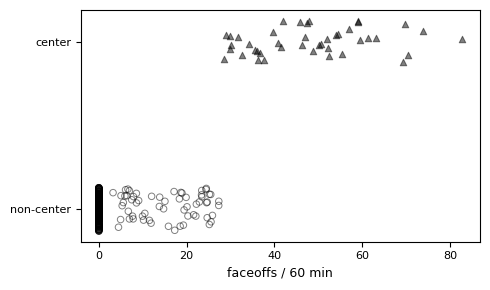

Saved → ../output/position_clustering/plot_a_faceoff_cluster.png


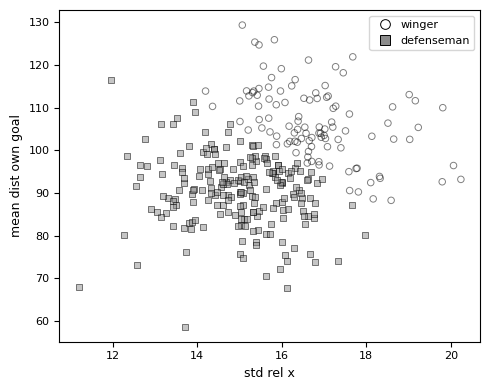

Saved → ../output/position_clustering/plot_b_winger_vs_def.png


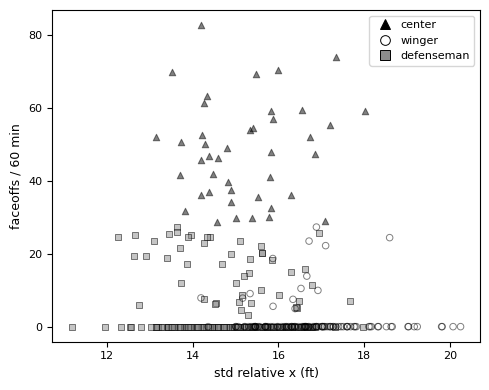

Saved → ../output/position_clustering/plot_c_all_positions.png


In [ ]:
import matplotlib.lines as mlines

OUT_CMP_DIR.mkdir(parents=True, exist_ok=True)

MK   = {'C': '^', 'F': 'o', 'D': 's'}
FC   = {'C': 'black', 'F': 'none', 'D': '0.55'}
EC   = {'C': 'black', 'F': 'black', 'D': 'black'}
MS, LW, ALPH = 22, 0.7, 0.5
RNG  = np.random.default_rng(99)

def pos_legend(ax, positions):
    labels = {'C': 'center', 'F': 'winger', 'D': 'defenseman'}
    handles = [
        mlines.Line2D([], [], marker=MK[p], color='w',
                      markerfacecolor=FC[p], markeredgecolor=EC[p],
                      markeredgewidth=LW, markersize=7, linestyle='None',
                      label=labels[p])
        for p in positions
    ]
    ax.legend(handles=handles, fontsize=8, frameon=True, handletextpad=0.4)

# ── Plot (a): Stage-1 faceoff strip ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
for pos_label, y_val, disp_pos in [('non-C', 0, 'F'), ('C', 1, 'C')]:
    mask = s1_df['stage1_pos'] == pos_label
    vals = s1_df.loc[mask, 'faceoffs_per_60'].values
    jit  = RNG.uniform(-0.13, 0.13, size=mask.sum())
    ax.scatter(vals, y_val + jit,
               marker=MK[disp_pos], facecolors=FC[disp_pos],
               edgecolors=EC[disp_pos], s=MS, linewidths=LW, alpha=ALPH)
ax.set_yticks([0, 1])
ax.set_yticklabels(['non-center', 'center'], fontsize=8)
ax.set_xlabel('faceoffs / 60 min', fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
f = OUT_CMP_DIR / 'plot_a_faceoff_cluster.png'
plt.savefig(f, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {f}')

# ── Plot (b): Stage-2 winger vs defenseman ────────────────────────────────────
feat_x = S2_CHOSEN_FEATS[0]
feat_y = S2_CHOSEN_FEATS[1] if len(S2_CHOSEN_FEATS) >= 2 else None

fig, ax = plt.subplots(figsize=(5, 4))
if feat_y is not None:
    for pos_label in ['D', 'F']:
        mask = s2_sub['stage2_pos'] == pos_label
        ax.scatter(s2_sub.loc[mask, feat_x], s2_sub.loc[mask, feat_y],
                   marker=MK[pos_label], facecolors=FC[pos_label],
                   edgecolors=EC[pos_label], s=MS, linewidths=LW, alpha=ALPH)
    ax.set_xlabel(feat_x.replace('_', ' '), fontsize=9)
    ax.set_ylabel(feat_y.replace('_', ' '), fontsize=9)
else:
    for pos_label, y_val in [('D', 0), ('F', 1)]:
        mask = s2_sub['stage2_pos'] == pos_label
        vals = s2_sub.loc[mask, feat_x].values
        jit  = RNG.uniform(-0.13, 0.13, size=mask.sum())
        ax.scatter(vals, y_val + jit,
                   marker=MK[pos_label], facecolors=FC[pos_label],
                   edgecolors=EC[pos_label], s=MS, linewidths=LW, alpha=ALPH)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['defenseman', 'winger'], fontsize=8)
    ax.set_xlabel(feat_x.replace('_', ' '), fontsize=9)
pos_legend(ax, ['F', 'D'])
ax.tick_params(labelsize=8)
plt.tight_layout()
f = OUT_CMP_DIR / 'plot_b_winger_vs_def.png'
plt.savefig(f, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {f}')

# ── Plot (c): std_rel_x vs faceoffs_per_60, all three positions ──────────────
plot3_df = (
    game_feat[['Game', 'Team', 'Player_Id', 'std_rel_x', 'faceoffs_per_60']]
    .merge(hier_out[['Game', 'Team', 'Player_Id', 'position']], on=['Game', 'Team', 'Player_Id'], how='inner')
    .dropna(subset=['position', 'faceoffs_per_60'])
)

fig, ax = plt.subplots(figsize=(5, 4))
for pos_label in ['D', 'F', 'C']:
    mask = plot3_df['position'] == pos_label
    ax.scatter(plot3_df.loc[mask, 'std_rel_x'], plot3_df.loc[mask, 'faceoffs_per_60'],
               marker=MK[pos_label], facecolors=FC[pos_label],
               edgecolors=EC[pos_label], s=MS, linewidths=LW, alpha=ALPH)
ax.set_xlabel('std relative x (ft)', fontsize=9)
ax.set_ylabel('faceoffs / 60 min', fontsize=9)
pos_legend(ax, ['C', 'F', 'D'])
ax.tick_params(labelsize=8)
plt.tight_layout()
f = OUT_CMP_DIR / 'plot_c_all_positions.png'
plt.savefig(f, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {f}')


In [ ]:
# ── Position label export ─────────────────────────────────────────────────────
# Two files:
#   position_labels.parquet        — one row per (Game, Team, Player_Id); join key for shift-level models
#   position_labels_player.parquet — one row per (Team, Player_Id); consensus label across all games
#
# Note: Player_Id is just a jersey number — the same jersey number can appear
# on different teams, so Team must always be part of the key.

# Per-game labels (primary join key for notebook 01 and others)
per_game = (
    hier_out[['Game', 'Team', 'Player_Id', 'position', 's1_prob', 's2_prob']]
    .dropna(subset=['position'])
    .copy()
)
per_game['conf'] = per_game.apply(
    lambda r: r['s1_prob'] if r['position'] == 'C' else r['s2_prob'], axis=1
)
per_game = per_game[['Game', 'Team', 'Player_Id', 'position', 'conf']].copy()

p1 = DATA_DIR / 'position_labels.parquet'
per_game.to_parquet(p1, index=False)
print(f'Per-game labels  → {p1}  ({len(per_game):,} rows)')
print(per_game['position'].value_counts().to_string())

# Consensus label per (Team, Player_Id) across all games (majority vote)
def majority(s):
    return s.value_counts().idxmax()

per_player = (
    per_game.groupby(['Team', 'Player_Id'])
    .agg(
        position=('position', majority),
        n_games=('Game', 'nunique'),
        mean_conf=('conf', 'mean'),
    )
    .reset_index()
)

p2 = DATA_DIR / 'position_labels_player.parquet'
per_player.to_parquet(p2, index=False)
print(f'\nPer-player labels → {p2}  ({len(per_player):,} team-player pairs)')
print(per_player['position'].value_counts().to_string())

print(f"""
── How to load in other notebooks ────────────────────────────────────────────
  # Per-game (join on Game + Team + Player_Id):
  pos = pd.read_parquet('../data/position_labels.parquet')
  df  = df.merge(pos[['Game', 'Team', 'Player_Id', 'position']],
                 on=['Game', 'Team', 'Player_Id'], how='left')

  # Per-player (join on Team + Player_Id — majority-vote label):
  pos_p = pd.read_parquet('../data/position_labels_player.parquet')
  df    = df.merge(pos_p[['Team', 'Player_Id', 'position']],
                   on=['Team', 'Player_Id'], how='left')

  # positions: 'C' = center, 'F' = winger, 'D' = defenseman, NaN = unknown
  # is_forward (for binary models): df['is_forward'] = (df['position'] != 'D').astype(int)
──────────────────────────────────────────────────────────────────────────────""")


Per-game labels  → ../data/position_labels.parquet  (356 rows)
position
D    210
F    104
C     42

Per-player labels → ../data/position_labels_player.parquet  (234 team-player pairs)
position
D    136
F     71
C     27

── How to load in other notebooks ────────────────────────────────────────────
  # Per-game (join on Game + Team + Player_Id):
  pos = pd.read_parquet('../data/position_labels.parquet')
  df  = df.merge(pos[['Game', 'Team', 'Player_Id', 'position']],
                 on=['Game', 'Team', 'Player_Id'], how='left')

  # Per-player (join on Team + Player_Id — majority-vote label):
  pos_p = pd.read_parquet('../data/position_labels_player.parquet')
  df    = df.merge(pos_p[['Team', 'Player_Id', 'position']],
                   on=['Team', 'Player_Id'], how='left')

  # positions: 'C' = center, 'F' = winger, 'D' = defenseman, NaN = unknown
  # is_forward (for binary models): df['is_forward'] = (df['position'] != 'D').astype(int)
──────────────────────────────────────────────